# 🧹 Lab 2.1 (การบ้านที่ 2) · Data Profiling ข้อมูลลูกค้า `customers.csv`
**ร้านกาแฟบ้านบรู · Basic Data Analytics and Data Visualization using AI Vibe Coding**

เป้าหมาย: ตรวจหาความผิดปกติของข้อมูลลูกค้า → รายงานเป็นตารางก่อน → ตัดสินใจทำความสะอาด → export `customers_clean.csv` ไปใช้แสดงผลบน Baanbrew Dashboard

> หลักการเดียวกับ Lab 2.1: **อย่าแก้ข้อมูลก่อน ให้รายงานปัญหาก่อน** ทุกการตัดสินใจต้องบันทึกว่าทำอะไร เพราะอะไร กระทบกี่แถว

| ขั้น | ทำอะไร |
|---|---|
| 1 | โหลดข้อมูล (customers + branches + sales สำหรับตรวจไขว้) |
| 2 | ภาพรวมโครงสร้าง + Data profiling รายคอลัมน์ |
| 3 | ตรวจความผิดปกติ 20 ข้อ → ตารางรายงานปัญหา |
| 4 | กราฟสำรวจข้อมูลดิบ |
| 5 | ทำความสะอาด + บันทึกการตัดสินใจ |
| 6 | ตรวจผลหลังทำความสะอาด + export |
| 7 | กราฟข้อมูลที่สะอาดแล้ว (ต้นแบบสำหรับ Dashboard) |

**วิธีใช้:** เมนู Runtime → Run all — ค่าเริ่มต้นจะดึงไฟล์จากเว็บ Dashboard ของเรา ถ้ามีไฟล์ `customers.csv` ต้นฉบับจากคอร์ส ให้อัปโหลดไว้ในแถบ 📁 Files ด้านซ้ายก่อน แล้ว Run all ใหม่ (โน้ตบุ๊กจะใช้ไฟล์ที่อัปโหลดก่อนเสมอ)

## 1) ตั้งค่าและโหลดข้อมูล
อ่านทุกคอลัมน์เป็นข้อความ (`dtype=str`) และไม่ให้ pandas แปลงค่าว่างเป็น NaN เอง เพื่อให้เห็นข้อมูล "ตามที่เป็นจริง" ก่อนตรวจ

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files  # มีเฉพาะตอนรันบน Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 60)

# ไฟล์ข้อมูลชุดเดียวกับที่ Dashboard ใช้ (ถ้ามีไฟล์ชื่อเดียวกันในเครื่อง/แถบ Files จะใช้ไฟล์นั้นก่อน)
DATA_URL = "https://opongpangs-star.github.io/baanbrew-lab1/"
DATA_END = pd.Timestamp("2026-09-20")  # วันสุดท้ายของข้อมูลยอดขาย

def load_csv(name, required=True):
    src = name if os.path.exists(name) else DATA_URL + name
    try:
        df = pd.read_csv(src, dtype=str, keep_default_na=False, encoding="utf-8-sig")
    except Exception as e:
        if required:
            raise
        print(f"⚠️ ไม่พบ {name} — จะข้ามการตรวจที่ต้องใช้ไฟล์นี้ ({type(e).__name__})")
        return None
    print(f"✅ {name:<14} {len(df):>7,} แถว × {df.shape[1]} คอลัมน์  ← {src}")
    return df

raw = load_csv("customers.csv")
branches = load_csv("branches.csv", required=False)  # ใช้ตรวจรหัส/ชื่อสาขา และวันเปิดสาขา
sales = load_csv("sales.csv", required=False)        # ใช้ตรวจไขว้ว่าสมาชิกซื้อจริงไหม
display(raw.head(10))

✅ customers.csv    3,000 แถว × 10 คอลัมน์  ← customers.csv
✅ branches.csv         5 แถว × 6 คอลัมน์  ← branches.csv
✅ sales.csv       53,057 แถว × 9 คอลัมน์  ← sales.csv


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone,home_branch,phone_shared,has_purchase
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693,สีลม,False,True
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734,บางนา,False,True
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286,บางนา,False,True
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314,มหาวิทยาลัย,False,False
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701,บางนา,False,True
5,C00006,กมล,ชาย,18-24,B04,2026-08-16,086-xxx-1895,บางนา,False,False
6,C00007,วรรณ,ชาย,45-54,B03,2026-07-17,087-xxx-3147,อารีย์,False,True
7,C00008,ภัทร,หญิง,25-34,B01,2026-04-07,087-xxx-9877,สยาม,False,True
8,C00009,ภัทร,ชาย,18-24,B04,2026-01-10,089-xxx-7309,บางนา,False,False
9,C00010,อัญชลี,หญิง,18-24,B04,2026-06-15,089-xxx-9676,บางนา,False,True


## 2) ภาพรวมโครงสร้าง + Data profiling รายคอลัมน์
คอลัมน์หลักของข้อมูลลูกค้า: `customer_id, nickname, gender, age_group, home_branch_id, joined_date, phone`
ถ้ามีคอลัมน์อื่นเพิ่มมา (เช่น `home_branch`, `phone_shared`, `has_purchase`) ถือว่าเป็นค่าที่มีคนคำนวณไว้ก่อน — เราจะตรวจว่าถูกไหม แล้วคำนวณใหม่เองตอนทำความสะอาด

In [2]:
CORE = ["customer_id", "nickname", "gender", "age_group", "home_branch_id", "joined_date", "phone"]
print("ขนาดข้อมูล:", raw.shape)
print("คอลัมน์หลักที่ขาด :", [c for c in CORE if c not in raw.columns] or "ไม่มี")
print("คอลัมน์เพิ่มเติม  :", [c for c in raw.columns if c not in CORE] or "ไม่มี")

def profile(df):
    """สรุปรายคอลัมน์: ค่าว่าง, ช่องว่างหัว/ท้าย, ค่าไม่ซ้ำ, ค่าที่พบบ่อย, ตัวอย่าง"""
    rows = []
    for c in df.columns:
        s = df[c].astype(str)
        st = s.str.strip()
        blank = int((st == "").sum())
        filled = st[st != ""]
        vc = filled.value_counts()
        rows.append({
            "คอลัมน์": c,
            "ค่าว่าง": blank,
            "% ว่าง": round(blank / len(df) * 100, 2),
            "ช่องว่างหัว/ท้าย": int(((s != st) & (st != "")).sum()),
            "ค่าไม่ซ้ำ": int(filled.nunique()),
            "ค่าที่พบบ่อย (top 3)": ", ".join(f"{k} ({v:,})" for k, v in vc.head(3).items()),
            "ความยาวต่ำสุด-สูงสุด": f"{filled.str.len().min()}-{filled.str.len().max()}" if len(filled) else "-",
        })
    return pd.DataFrame(rows)

display(profile(raw))

ขนาดข้อมูล: (3000, 10)
คอลัมน์หลักที่ขาด : ไม่มี
คอลัมน์เพิ่มเติม  : ['home_branch', 'phone_shared', 'has_purchase']


,คอลัมน์,ค่าว่าง,% ว่าง,ช่องว่างหัว/ท้าย,ค่าไม่ซ้ำ,ค่าที่พบบ่อย (top 3),ความยาวต่ำสุด-สูงสุด
0,customer_id,0,0.0,0,3000,"C00001 (1), C00002 (1), C00003 (1)",6-6
1,nickname,0,0.0,0,24,"อัญชลี (148), รัตนา (140), กมล (138)",3-6
2,gender,0,0.0,0,3,"หญิง (1,652), ชาย (1,232), ไม่ระบุ (116)",3-7
3,age_group,0,0.0,0,6,"25-34 (993), 18-24 (775), 35-44 (577)",3-10
4,home_branch_id,0,0.0,0,5,"B01 (776), B05 (693), B02 (643)",3-3
5,joined_date,0,0.0,0,530,"2025-10-20 (13), 2026-02-04 (13), 2026-08-26 (13)",10-10
6,phone,0,0.0,0,2950,"083-xxx-5083 (3), 088-xxx-7647 (2), 088-xxx-4229 (2)",12-12
7,home_branch,0,0.0,0,5,"สยาม (776), มหาวิทยาลัย (693), สีลม (643)",4-11
8,phone_shared,0,0.0,0,2,"False (2,901), True (99)",4-5
9,has_purchase,0,0.0,0,2,"True (2,507), False (493)",4-5


In [3]:
# การกระจายของคอลัมน์แบบกลุ่ม (categorical) — ค่าแปลก ๆ มักโผล่ตรงนี้
for c in ["gender", "age_group", "home_branch_id", "home_branch", "phone_shared", "has_purchase"]:
    if c in raw.columns:
        print(f"\n▶ {c}")
        print(raw[c].value_counts(dropna=False).to_string())


▶ gender
gender
หญิง       1652
ชาย        1232
ไม่ระบุ     116

▶ age_group
age_group
25-34         993
18-24         775
35-44         577
45-54         346
55+           196
ต่ำกว่า 18    113

▶ home_branch_id
home_branch_id
B01    776
B05    693
B02    643
B04    483
B03    405

▶ home_branch
home_branch
สยาม           776
มหาวิทยาลัย    693
สีลม           643
บางนา          483
อารีย์         405

▶ phone_shared
phone_shared
False    2901
True       99

▶ has_purchase
has_purchase
True     2507
False     493


## 3) ตรวจความผิดปกติ → ตารางรายงานปัญหา (ยังไม่แก้ข้อมูล)
ตรวจ 3 ระดับ
1. **โครงสร้าง/รูปแบบ** — แถวซ้ำ, รหัสซ้ำ, ค่าว่าง, รูปแบบรหัส/วันที่/เบอร์โทรผิด, ค่ากลุ่มไม่มาตรฐาน
2. **ความสมเหตุสมผล** — วันสมัครในอนาคต, สมัครก่อนสาขาเปิด, รหัสสาขาไม่ตรงชื่อสาขา
3. **ตรวจไขว้กับยอดขาย (sales.csv)** — สมาชิกไม่เคยซื้อ, ซื้อก่อนสมัคร, สาขาประจำไม่ตรงกับที่ซื้อจริง, รหัสในยอดขายที่ไม่มีในทะเบียน

In [4]:
GENDER_OK = {"ชาย", "หญิง", "ไม่ระบุ"}
AGE_ORDER = ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"]
if branches is not None:
    BRANCH = branches.set_index("branch_id")
else:  # สำรองไว้ถ้าไม่มีไฟล์ branches.csv
    BRANCH = pd.DataFrame({"branch": ["สยาม", "สีลม", "อารีย์", "บางนา", "มหาวิทยาลัย"],
                           "opened_date": ["2023-06-01", "2023-09-15", "2025-11-01", "2024-03-01", "2024-06-01"]},
                          index=["B01", "B02", "B03", "B04", "B05"])

def parse_thai_date(v):
    """คืน (วันที่, รูปแบบ) รองรับ YYYY-MM-DD, DD/MM/YYYY และปี พ.ศ. (ปี > 2400 → ลบ 543)"""
    v = str(v).strip()
    if not v:
        return pd.NaT, "ว่าง"
    m = re.fullmatch(r"(\d{4})-(\d{1,2})-(\d{1,2})(?:[ T].*)?", v)
    if m:
        y, mo, d = map(int, m.groups()); kind = "ISO"
    else:
        m = re.fullmatch(r"(\d{1,2})/(\d{1,2})/(\d{4})", v)
        if not m:
            return pd.NaT, "อ่านไม่ได้"
        d, mo, y = map(int, m.groups()); kind = "DD/MM/YYYY"
    if y > 2400:
        y -= 543; kind += " (พ.ศ.)"
    try:
        return pd.Timestamp(year=y, month=mo, day=d), kind
    except ValueError:
        return pd.NaT, "อ่านไม่ได้"

s = raw.apply(lambda col: col.astype(str).str.strip())  # ค่าหลังตัดช่องว่าง ใช้ "ตรวจ" เท่านั้น (raw ยังไม่ถูกแก้)
parsed = s["joined_date"].apply(parse_thai_date)
s_date = pd.to_datetime(parsed.str[0])
s_kind = parsed.str[1]

issues, flags = [], pd.DataFrame(index=raw.index)

def check(name, mask, fix, ask, col=None, level="รูปแบบ"):
    mask = pd.Series(mask, index=raw.index).fillna(False).astype(bool)
    flags[name] = mask
    sample = raw.loc[mask, col].astype(str).drop_duplicates().head(3).tolist() if col and mask.any() else []
    issues.append({"ระดับ": level, "ปัญหา": name, "จำนวนแถว": int(mask.sum()),
                   "ตัวอย่าง": ", ".join(sample), "แนวทางแก้ (เสนอ)": fix, "ควรถามใคร": ask})

cid = s["customer_id"]
check("แถวซ้ำทุกคอลัมน์", s.duplicated(keep="first"), "ลบแถวซ้ำ เก็บแถวแรก", "ทีม CRM/POS", "customer_id")
check("customer_id ว่าง", cid == "", "ลบทิ้ง (อ้างอิงยอดขายไม่ได้)", "ทีม CRM", "nickname")
check("customer_id รูปแบบผิด (ไม่ใช่ C + 5 หลัก)", (cid != "") & ~cid.str.fullmatch(r"C\d{5}"), "แปลงเป็นตัวพิมพ์ใหญ่/เติม 0 ถ้าเดาได้ ไม่งั้นแจ้งทีม", "ทีม CRM", "customer_id")
check("customer_id ซ้ำแต่ข้อมูลต่างกัน", cid.duplicated(keep=False) & ~s.duplicated(keep=False) & (cid != ""), "เก็บแถวที่สมัครก่อน แล้วส่งรายชื่อให้ตรวจ", "ทีม CRM — คนเดียวกันหรือคนละคน?", "customer_id")
check("มีช่องว่างหัว/ท้ายข้อความ", (raw.astype(str) != s).any(axis=1), "ตัดช่องว่าง (strip)", "-", "nickname")
check("nickname ว่าง", s["nickname"] == "", "เก็บไว้ ใส่ 'ไม่ระบุ'", "-", "customer_id")
check("gender ไม่มาตรฐาน", ~s["gender"].isin(GENDER_OK), "แปลงคำพ้อง (M/ช/male → ชาย ...) ที่เหลือเป็น 'ไม่ระบุ'", "-", "gender")
check("age_group ไม่มาตรฐาน", ~s["age_group"].isin(AGE_ORDER), "แปลงรูปแบบให้ตรงกลุ่ม ไม่งั้น 'ไม่ระบุ'", "-", "age_group")
check("home_branch_id ไม่มีในรายชื่อสาขา", ~s["home_branch_id"].str.upper().isin(BRANCH.index), "เดาจากชื่อสาขาถ้ามี ไม่งั้นแจ้งทีม", "ทีม POS", "home_branch_id")
if "home_branch" in s:
    check("home_branch ไม่ตรงกับ home_branch_id", s["home_branch_id"].map(BRANCH["branch"]) != s["home_branch"], "ยึดรหัสสาขา แล้วเติมชื่อจาก branches.csv", "ทีม POS", "home_branch", "สมเหตุสมผล")
check("joined_date ว่าง/อ่านไม่ได้", s_date.isna(), "เก็บลูกค้าไว้ ปล่อยวันที่ว่าง (ไม่นับในกราฟสมัครรายเดือน)", "ทีม CRM", "joined_date")
check("joined_date เป็นปี พ.ศ.", s_kind.str.contains("พ.ศ.", regex=False), "ลบ 543 ปี", "-", "joined_date")
check("joined_date รูปแบบ DD/MM/YYYY", s_kind.str.startswith("DD/MM"), "แปลงเป็น YYYY-MM-DD", "-", "joined_date")
check("joined_date หลังวันสุดท้ายของข้อมูล", s_date > DATA_END, "ตั้งเป็นค่าว่าง + ตรวจกับระบบสมาชิก", "ทีม CRM", "joined_date", "สมเหตุสมผล")
opened = pd.to_datetime(s["home_branch_id"].str.upper().map(BRANCH["opened_date"]))
check("สมัครก่อนสาขาประจำเปิด", s_date < opened, "เก็บไว้ + ติดธง (อาจย้ายสาขาภายหลัง)", "ผู้จัดการสาขา", "joined_date", "สมเหตุสมผล")
check("เบอร์โทรรูปแบบผิด", ~s["phone"].str.fullmatch(r"0\d{2}-xxx-\d{4}") & ~s["phone"].str.fullmatch(r"0\d{2}-?\d{3}-?\d{4}"), "ปล่อยว่าง", "ทีม CRM", "phone")
check("เบอร์โทรไม่ได้ปิดบัง (เสี่ยง PDPA)", s["phone"].str.fullmatch(r"0\d{2}-?\d{3}-?\d{4}"), "ปิดบังเป็น 0XX-xxx-XXXX ก่อนใช้งาน", "ฝ่ายกฎหมาย/DPO", None, "สมเหตุสมผล")
check("เบอร์โทรซ้ำกับลูกค้าคนอื่น", (s["phone"] != "") & s["phone"].duplicated(keep=False), "ไม่ลบ ติดธง phone_shared (อาจเป็นคนในบ้านเดียวกัน หรือสมัครซ้ำ)", "ทีม CRM — สมัครซ้ำหรือไม่?", "phone", "สมเหตุสมผล")
check("อายุต่ำกว่า 18 ปี", s["age_group"] == "ต่ำกว่า 18", "เก็บไว้ ติดธง is_minor (ต้องมีความยินยอมผู้ปกครองตาม PDPA)", "ฝ่ายกฎหมาย/DPO", "customer_id", "สมเหตุสมผล")

orphans = pd.DataFrame()
if sales is not None:
    sl = sales[sales["customer_id"].str.strip() != ""].copy()
    sl["customer_id"] = sl["customer_id"].str.strip()
    sl["date"] = pd.to_datetime(sl["datetime"].str[:10])
    first_buy = sl.groupby("customer_id")["date"].min()
    top_branch = sl.drop_duplicates("order_id").groupby("customer_id")["branch"].agg(lambda b: b.value_counts().index[0])
    check("สมาชิกที่ไม่เคยซื้อเลย", ~cid.isin(first_buy.index), "เก็บไว้ ติดธง has_purchase=False (กลุ่มเป้าหมายทำโปรฯ)", "ทีมการตลาด", "customer_id", "ตรวจไขว้")
    check("ซื้อครั้งแรกก่อนวันสมัคร", cid.map(first_buy) < s_date, "เก็บไว้ ติดธง (วันสมัครอาจบันทึกผิด)", "ทีม CRM", "customer_id", "ตรวจไขว้")
    check("สาขาประจำ ≠ สาขาที่ซื้อบ่อยที่สุด", cid.isin(top_branch.index) & (cid.map(top_branch) != s["home_branch_id"].str.upper().map(BRANCH["branch"])), "เก็บไว้ เพิ่มคอลัมน์ top_branch", "ทีมการตลาด", "customer_id", "ตรวจไขว้")
    if "has_purchase" in s:
        check("has_purchase เดิมไม่ตรงกับยอดขายจริง", (s["has_purchase"] == "True") != cid.isin(first_buy.index), "คำนวณใหม่จาก sales.csv", "-", "customer_id", "ตรวจไขว้")
    orphans = sl.loc[~sl["customer_id"].isin(cid), "customer_id"].drop_duplicates()
    issues.append({"ระดับ": "ตรวจไขว้", "ปัญหา": "customer_id ในยอดขายที่ไม่มีในทะเบียนลูกค้า", "จำนวนแถว": len(orphans),
                   "ตัวอย่าง": ", ".join(orphans.head(3)), "แนวทางแก้ (เสนอ)": "ส่งรายชื่อให้ทีมเพิ่มเข้าทะเบียน", "ควรถามใคร": "ทีม CRM/POS"})

report = pd.DataFrame(issues)
report.insert(3, "% ของแถว", (report["จำนวนแถว"] / len(raw) * 100).round(2))
report = report.sort_values(["จำนวนแถว"], ascending=False, kind="stable").reset_index(drop=True)
print(f"ตรวจทั้งหมด {len(report)} ข้อ · พบปัญหา {int((report['จำนวนแถว'] > 0).sum())} ข้อ · แถวที่มีปัญหาอย่างน้อย 1 ข้อ {int(flags.any(axis=1).sum()):,} / {len(raw):,} แถว")
display(report)

ตรวจทั้งหมด 24 ข้อ · พบปัญหา 4 ข้อ · แถวที่มีปัญหาอย่างน้อย 1 ข้อ 778 / 3,000 แถว


,ระดับ,ปัญหา,จำนวนแถว,% ของแถว,ตัวอย่าง,แนวทางแก้ (เสนอ),ควรถามใคร
0,ตรวจไขว้,สมาชิกที่ไม่เคยซื้อเลย,493,16.43,"C00004, C00006, C00009",เก็บไว้ ติดธง has_purchase=False (กลุ่มเป้าหมายทำโปรฯ),ทีมการตลาด
1,สมเหตุสมผล,อายุต่ำกว่า 18 ปี,113,3.77,"C00013, C00038, C00048",เก็บไว้ ติดธง is_minor (ต้องมีความยินยอมผู้ปกครองตาม PDPA),ฝ่ายกฎหมาย/DPO
2,ตรวจไขว้,สาขาประจำ ≠ สาขาที่ซื้อบ่อยที่สุด,107,3.57,"C00095, C00150, C00188",เก็บไว้ เพิ่มคอลัมน์ top_branch,ทีมการตลาด
3,สมเหตุสมผล,เบอร์โทรซ้ำกับลูกค้าคนอื่น,99,3.30,"088-xxx-7647, 088-xxx-4229, 088-xxx-5690",ไม่ลบ ติดธง phone_shared (อาจเป็นคนในบ้านเดียวกัน หรือสมัครซ้ำ),ทีม CRM — สมัครซ้ำหรือไม่?
4,รูปแบบ,แถวซ้ำทุกคอลัมน์,0,0.00,,ลบแถวซ้ำ เก็บแถวแรก,ทีม CRM/POS
5,รูปแบบ,customer_id ว่าง,0,0.00,,ลบทิ้ง (อ้างอิงยอดขายไม่ได้),ทีม CRM
6,รูปแบบ,customer_id รูปแบบผิด (ไม่ใช่ C + 5 หลัก),0,0.00,,แปลงเป็นตัวพิมพ์ใหญ่/เติม 0 ถ้าเดาได้ ไม่งั้นแจ้งทีม,ทีม CRM
7,รูปแบบ,customer_id ซ้ำแต่ข้อมูลต่างกัน,0,0.00,,เก็บแถวที่สมัครก่อน แล้วส่งรายชื่อให้ตรวจ,ทีม CRM — คนเดียวกันหรือคนละคน?
8,รูปแบบ,มีช่องว่างหัว/ท้ายข้อความ,0,0.00,,ตัดช่องว่าง (strip),-
9,รูปแบบ,nickname ว่าง,0,0.00,,เก็บไว้ ใส่ 'ไม่ระบุ',-


## 4) กราฟสำรวจข้อมูลดิบ
ตั้งฟอนต์ไทยก่อน (Colab ไม่มีฟอนต์ไทยมาให้ ถ้าไม่ตั้งจะเห็นตัวอักษรเป็นสี่เหลี่ยม)

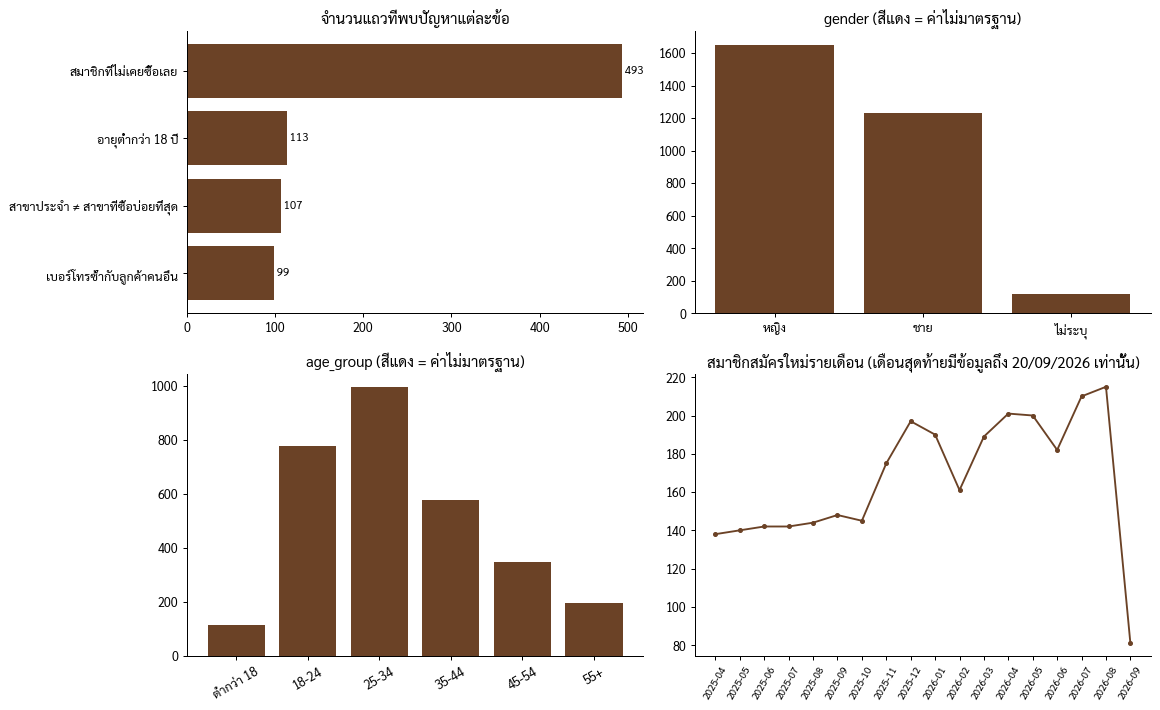

In [5]:
from matplotlib import font_manager
import urllib.request

FONT = "Sarabun-Regular.ttf"
try:
    if not os.path.exists(FONT):
        urllib.request.urlretrieve("https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf", FONT)
    font_manager.fontManager.addfont(FONT)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=FONT).get_name()
except Exception as e:
    print("⚠️ โหลดฟอนต์ไทยไม่สำเร็จ ตัวอักษรไทยในกราฟอาจไม่แสดง:", type(e).__name__)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
BROWN, LIGHT = "#6b4226", "#d9c3a5"

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
found = report[report["จำนวนแถว"] > 0].sort_values("จำนวนแถว")
axes[0, 0].barh(found["ปัญหา"], found["จำนวนแถว"], color=BROWN)
axes[0, 0].set_title("จำนวนแถวที่พบปัญหาแต่ละข้อ")
for i, v in enumerate(found["จำนวนแถว"]):
    axes[0, 0].text(int(v), i, f" {int(v):,}", va="center", fontsize=9)

g = s["gender"].value_counts()
axes[0, 1].bar(g.index, g.values, color=[BROWN if k in GENDER_OK else "#c0392b" for k in g.index])
axes[0, 1].set_title("gender (สีแดง = ค่าไม่มาตรฐาน)")

a = s["age_group"].value_counts()
a = a.reindex([x for x in AGE_ORDER if x in a.index] + [x for x in a.index if x not in AGE_ORDER])
axes[1, 0].bar(a.index, a.values, color=[BROWN if k in AGE_ORDER else "#c0392b" for k in a.index])
axes[1, 0].set_title("age_group (สีแดง = ค่าไม่มาตรฐาน)")
axes[1, 0].tick_params(axis="x", rotation=30)

m = s_date.dropna().dt.to_period("M").value_counts().sort_index()
axes[1, 1].plot(m.index.astype(str), m.values, color=BROWN, marker="o", ms=3)
axes[1, 1].set_title("สมาชิกสมัครใหม่รายเดือน (เดือนสุดท้ายมีข้อมูลถึง " + DATA_END.strftime("%d/%m/%Y") + " เท่านั้น)")
axes[1, 1].tick_params(axis="x", rotation=60, labelsize=8)
plt.tight_layout()
plt.show()

## 5) ทำความสะอาด + บันทึกการตัดสินใจ
การทำความสะอาดคือ **การตัดสินใจทางธุรกิจ** — หลักที่ใช้: ลบเฉพาะแถวที่ใช้งานไม่ได้จริง (ซ้ำ/ไม่มีรหัส) ส่วนปัญหาเชิงธุรกิจให้ **เก็บไว้และติดธง** เพื่อให้คนที่รู้ธุรกิจตัดสินต่อ

| เจอ | ตัดสินใจ | เหตุผล |
|---|---|---|
| แถวซ้ำทุกคอลัมน์ | ลบ เก็บแถวแรก | ระบบส่งข้อมูลซ้ำ ไม่ใช่ลูกค้าใหม่ |
| customer_id ว่าง | ลบ | อ้างอิงยอดขายไม่ได้ |
| customer_id ซ้ำแต่ข้อมูลต่าง | เก็บแถวที่สมัครก่อน | สมาชิก 1 คนควรมีรหัสเดียว · ส่งรายชื่อให้ทีม CRM ตรวจ |
| gender / age_group ไม่มาตรฐาน | แปลงคำพ้องให้ตรงกลุ่ม ที่เหลือ = "ไม่ระบุ" | ไม่ทิ้งลูกค้า แค่ไม่รู้ข้อมูลส่วนนี้ |
| วันที่ พ.ศ. / DD/MM/YYYY | แปลงเป็น ค.ศ. YYYY-MM-DD | รูปแบบเดียวกันทั้งไฟล์ |
| วันที่อ่านไม่ได้ / ในอนาคต | ปล่อยว่าง + ติดธง | ไม่เดาวันที่เอง |
| เบอร์ไม่ปิดบัง | ปิดบังเป็น 0XX-xxx-XXXX | ลดความเสี่ยง PDPA |
| เบอร์ซ้ำ / อายุต่ำกว่า 18 / ไม่เคยซื้อ | เก็บไว้ + ติดธง | ไม่ใช่ข้อมูลผิด แต่เป็นข้อมูลที่ธุรกิจต้องรู้ |

In [6]:
GENDER_MAP = {"ชาย": "ชาย", "ช": "ชาย", "ผู้ชาย": "ชาย", "m": "ชาย", "male": "ชาย", "man": "ชาย",
              "หญิง": "หญิง", "ญ": "หญิง", "ผู้หญิง": "หญิง", "f": "หญิง", "female": "หญิง", "woman": "หญิง"}
AGE_ALIAS = {a.replace(" ", ""): a for a in AGE_ORDER}
AGE_ALIAS.update({"<18": "ต่ำกว่า 18", "under18": "ต่ำกว่า 18", "ไม่ถึง18": "ต่ำกว่า 18",
                  "55ขึ้นไป": "55+", ">55": "55+", "55-64": "55+", "65+": "55+"})
NAME_TO_ID = {v: k for k, v in BRANCH["branch"].items()}
NAME_TO_ID.update({f"สาขา{v}": k for k, v in BRANCH["branch"].items()})

def norm_age(v):
    k = str(v).replace(" ", "").replace("–", "-").replace("—", "-").lower()
    return AGE_ALIAS.get(k, "ไม่ระบุ")

def mask_phone(v):
    digits = re.sub(r"\D", "", str(v))
    if re.fullmatch(r"0\d{2}-xxx-\d{4}", str(v)):
        return v
    if len(digits) == 10 and digits.startswith("0"):
        return f"{digits[:3]}-xxx-{digits[-4:]}"
    return ""

log = []  # บันทึกทุกขั้น: ทำอะไร / กระทบกี่แถว / เหตุผล
def note(step, n, why):
    log.append({"ขั้นตอน": step, "จำนวนแถวที่กระทบ": int(n), "เหตุผล": why})

df = raw.apply(lambda col: col.astype(str).str.strip())
note("ตัดช่องว่างหัว/ท้ายทุกคอลัมน์", (raw.astype(str) != df).any(axis=1).sum(), "ป้องกันค่าเดียวกันถูกนับเป็นคนละค่า")

n = len(df); df = df.drop_duplicates()
note("ลบแถวซ้ำทุกคอลัมน์", n - len(df), "ข้อมูลส่งซ้ำ")

n = len(df); df = df[df["customer_id"] != ""]
note("ลบแถวที่ไม่มี customer_id", n - len(df), "อ้างอิงยอดขายไม่ได้")

df["customer_id"] = df["customer_id"].str.upper()
parsed = df["joined_date"].apply(parse_thai_date)
df["joined_date"] = pd.to_datetime(parsed.str[0])
note("แปลงวันที่ พ.ศ./DD-MM-YYYY เป็น ค.ศ. ISO", (~parsed.str[1].isin(["ISO", "ว่าง", "อ่านไม่ได้"])).sum(), "รูปแบบวันที่เดียวกันทั้งไฟล์")
future = df["joined_date"] > DATA_END
df.loc[future, "joined_date"] = pd.NaT
note("วันสมัครในอนาคต → ค่าว่าง", future.sum(), "ไม่เดาวันที่เอง")

n = len(df)
df = df.sort_values(["customer_id", "joined_date"], na_position="last").drop_duplicates("customer_id", keep="first")
note("customer_id ซ้ำ → เก็บแถวที่สมัครก่อน", n - len(df), "สมาชิก 1 คนมีรหัสเดียว")

old = df["gender"].copy()
df["gender"] = df["gender"].map(lambda v: GENDER_MAP.get(str(v).lower(), "ไม่ระบุ" if v not in GENDER_OK else v))
note("ปรับ gender ให้เป็น ชาย/หญิง/ไม่ระบุ", (old != df["gender"]).sum(), "ค่ามาตรฐาน 3 กลุ่ม")

old = df["age_group"].copy()
df["age_group"] = df["age_group"].map(norm_age)
note("ปรับ age_group ให้ตรง 6 กลุ่ม", (old != df["age_group"]).sum(), "ค่ามาตรฐานสำหรับกราฟ")

old = df["home_branch_id"].copy()
bid = df["home_branch_id"].str.upper()
if "home_branch" in df:
    bid = bid.where(bid.isin(BRANCH.index), df["home_branch"].map(NAME_TO_ID))
df["home_branch_id"] = bid.where(bid.isin(BRANCH.index), "")
df["home_branch"] = df["home_branch_id"].map(BRANCH["branch"]).fillna("ไม่ระบุ")
note("แก้รหัสสาขา + เติมชื่อสาขาจาก branches.csv", (old != df["home_branch_id"]).sum(), "ใช้ branches.csv เป็นแหล่งอ้างอิงเดียว")

old = df["phone"].copy()
df["phone"] = df["phone"].map(mask_phone)
note("ปิดบัง/ล้างเบอร์โทร", (old != df["phone"]).sum(), "PDPA + รูปแบบเดียวกัน")
df["nickname"] = df["nickname"].replace("", "ไม่ระบุ")

# ธง (flag) — ไม่ลบ แต่ทำเครื่องหมายไว้ให้ธุรกิจตัดสิน
df["phone_shared"] = (df["phone"] != "") & df["phone"].duplicated(keep=False)
df["is_minor"] = df["age_group"] == "ต่ำกว่า 18"
df["joined_before_branch_open"] = df["joined_date"] < pd.to_datetime(df["home_branch_id"].map(BRANCH["opened_date"]))

# สรุปพฤติกรรมการซื้อจาก sales.csv (ใช้ต่อใน Dashboard)
if sales is not None:
    sl = sales[sales["customer_id"].str.strip() != ""].copy()
    sl["customer_id"] = sl["customer_id"].str.strip().str.upper()
    sl["date"] = pd.to_datetime(sl["datetime"].str[:10])
    sl["revenue"] = pd.to_numeric(sl["qty"], errors="coerce") * pd.to_numeric(sl["unit_price"], errors="coerce")
    g = sl.groupby("customer_id")
    buy = pd.DataFrame({
        "orders": g["order_id"].nunique(),
        "total_spend": g["revenue"].sum().round(0),
        "first_purchase": g["date"].min(),
        "last_purchase": g["date"].max(),
        "top_branch": sl.drop_duplicates("order_id").groupby("customer_id")["branch"].agg(lambda b: b.value_counts().index[0]),
    })
    df = df.drop(columns=[c for c in buy.columns if c in df.columns]).merge(buy, left_on="customer_id", right_index=True, how="left")
    df["orders"] = df["orders"].fillna(0).astype(int)
    df["total_spend"] = df["total_spend"].fillna(0).astype(int)
    df["has_purchase"] = df["orders"] > 0
    df["bought_before_joined"] = df["first_purchase"] < df["joined_date"]
    note("คำนวณ has_purchase / orders / total_spend / top_branch ใหม่จาก sales.csv", len(df), "ไม่เชื่อค่าที่คำนวณมาก่อน")

COLS = ["customer_id", "nickname", "gender", "age_group", "home_branch_id", "home_branch", "joined_date", "phone",
        "phone_shared", "is_minor", "joined_before_branch_open", "has_purchase", "orders", "total_spend",
        "first_purchase", "last_purchase", "top_branch", "bought_before_joined"]
clean = df[[c for c in COLS if c in df.columns]].sort_values("customer_id").reset_index(drop=True)
note("ผลลัพธ์: ลูกค้าที่สะอาดแล้ว", len(clean), f"จากข้อมูลดิบ {len(raw):,} แถว · ตัดออก {len(raw) - len(clean):,} แถว")
display(pd.DataFrame(log))

,ขั้นตอน,จำนวนแถวที่กระทบ,เหตุผล
0,ตัดช่องว่างหัว/ท้ายทุกคอลัมน์,0,ป้องกันค่าเดียวกันถูกนับเป็นคนละค่า
1,ลบแถวซ้ำทุกคอลัมน์,0,ข้อมูลส่งซ้ำ
2,ลบแถวที่ไม่มี customer_id,0,อ้างอิงยอดขายไม่ได้
3,แปลงวันที่ พ.ศ./DD-MM-YYYY เป็น ค.ศ. ISO,0,รูปแบบวันที่เดียวกันทั้งไฟล์
4,วันสมัครในอนาคต → ค่าว่าง,0,ไม่เดาวันที่เอง
5,customer_id ซ้ำ → เก็บแถวที่สมัครก่อน,0,สมาชิก 1 คนมีรหัสเดียว
6,ปรับ gender ให้เป็น ชาย/หญิง/ไม่ระบุ,0,ค่ามาตรฐาน 3 กลุ่ม
7,ปรับ age_group ให้ตรง 6 กลุ่ม,0,ค่ามาตรฐานสำหรับกราฟ
8,แก้รหัสสาขา + เติมชื่อสาขาจาก branches.csv,0,ใช้ branches.csv เป็นแหล่งอ้างอิงเดียว
9,ปิดบัง/ล้างเบอร์โทร,0,PDPA + รูปแบบเดียวกัน


## 6) ตรวจผลหลังทำความสะอาด + export
ใช้ `assert` เป็นด่านตรวจ — ถ้ามีข้อไหนไม่ผ่าน เซลล์จะหยุดพร้อมบอกว่าผิดตรงไหน

In [7]:
assert clean["customer_id"].is_unique, "customer_id ยังซ้ำ"
odd_id = ~clean["customer_id"].str.fullmatch(r"C\d{5}")
if odd_id.any():  # ไม่ลบ แต่แสดงให้ทีม CRM ตรวจ
    print(f"ℹ️ รหัสลูกค้ารูปแบบไม่มาตรฐาน {int(odd_id.sum())} รหัส:", clean.loc[odd_id, "customer_id"].head(5).tolist())
assert clean["gender"].isin(GENDER_OK).all(), "gender ยังมีค่านอกมาตรฐาน"
assert clean["age_group"].isin(AGE_ORDER + ["ไม่ระบุ"]).all(), "age_group ยังมีค่านอกมาตรฐาน"
assert clean["home_branch"].isin(list(BRANCH["branch"]) + ["ไม่ระบุ"]).all(), "home_branch ยังมีค่านอกรายชื่อสาขา"
assert (clean["joined_date"].dropna() <= DATA_END).all(), "ยังมีวันสมัครในอนาคต"
print("✅ ผ่านการตรวจทุกข้อ")

hp = clean["has_purchase"] if "has_purchase" in clean else pd.Series(False, index=clean.index)
summary = pd.DataFrame({
    "ตัวชี้วัด": ["ลูกค้าทั้งหมด", "เคยซื้ออย่างน้อย 1 ครั้ง", "ยังไม่เคยซื้อ", "ใช้เบอร์ร่วมกัน", "อายุต่ำกว่า 18", "วันสมัครว่าง"],
    "จำนวน": [len(clean), int(hp.sum()), int((~hp).sum()), int(clean["phone_shared"].sum()),
              int(clean["is_minor"].sum()), int(clean["joined_date"].isna().sum())],
})
summary["%"] = (summary["จำนวน"] / len(clean) * 100).round(1)
display(summary)

out = clean.copy()
for c in ["joined_date", "first_purchase", "last_purchase"]:
    if c in out:
        out[c] = out[c].dt.strftime("%Y-%m-%d").fillna("")
out.to_csv("customers_clean.csv", index=False, encoding="utf-8-sig")
report.to_csv("customers_profiling_report.csv", index=False, encoding="utf-8-sig")
print("💾 บันทึก customers_clean.csv และ customers_profiling_report.csv แล้ว")
if IN_COLAB:
    files.download("customers_clean.csv")

✅ ผ่านการตรวจทุกข้อ
💾 บันทึก customers_clean.csv และ customers_profiling_report.csv แล้ว


,ตัวชี้วัด,จำนวน,%
0,ลูกค้าทั้งหมด,3000,100.0
1,เคยซื้ออย่างน้อย 1 ครั้ง,2507,83.6
2,ยังไม่เคยซื้อ,493,16.4
3,ใช้เบอร์ร่วมกัน,99,3.3
4,อายุต่ำกว่า 18,113,3.8
5,วันสมัครว่าง,0,0.0


## 7) กราฟข้อมูลลูกค้าที่สะอาดแล้ว — ต้นแบบของหน้า "ลูกค้า" บน Dashboard
คำถาม → ตัวชี้วัด → กราฟ
- ลูกค้าสมาชิกอยู่สาขาไหน และกี่ % ที่ซื้อจริง → แท่งซ้อน (ซื้อแล้ว/ยังไม่ซื้อ) แยกสาขา
- ลูกค้าแต่ละสาขาเป็นคนวัยไหน → แท่งซ้อน 100% ตามกลุ่มอายุ
- สมาชิกโตขึ้นไหม → กราฟเส้นสมาชิกใหม่รายเดือน (+ สะสม)

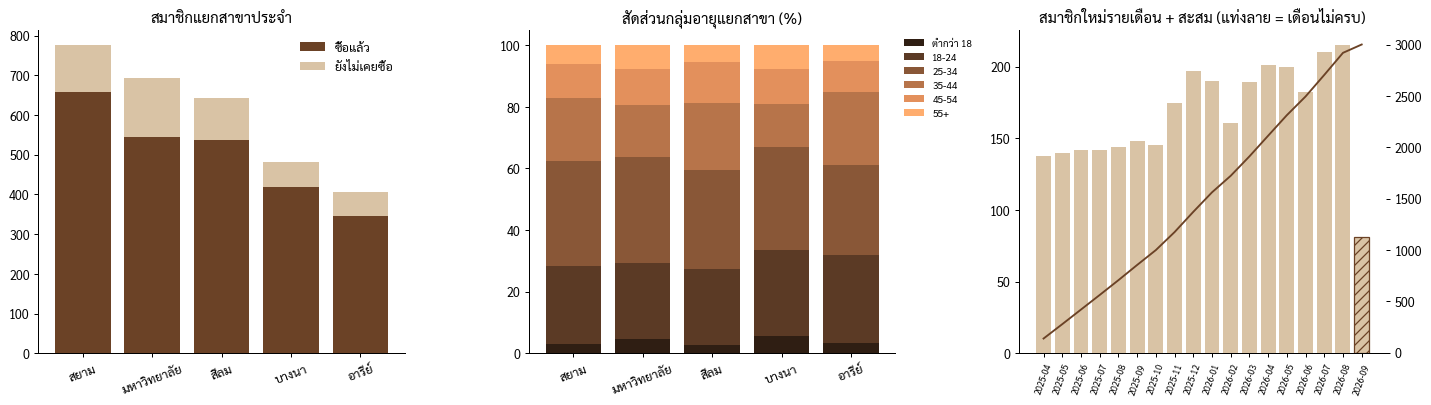

In [8]:
order = clean["home_branch"].value_counts().index
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

if "has_purchase" in clean:
    hb = pd.crosstab(clean["home_branch"], clean["has_purchase"]).reindex(order)
    axes[0].bar(hb.index, hb.get(True, 0), color=BROWN, label="ซื้อแล้ว")
    axes[0].bar(hb.index, hb.get(False, 0), bottom=hb.get(True, 0), color=LIGHT, label="ยังไม่เคยซื้อ")
    axes[0].legend(frameon=False)
axes[0].set_title("สมาชิกแยกสาขาประจำ")

ag = pd.crosstab(clean["home_branch"], clean["age_group"], normalize="index").reindex(order)
ag = ag[[c for c in AGE_ORDER + ["ไม่ระบุ"] if c in ag.columns]] * 100
bottom = np.zeros(len(ag))
for i, c in enumerate(ag.columns):
    axes[1].bar(ag.index, ag[c], bottom=bottom, label=c, color=plt.cm.copper(0.15 + i / (len(ag.columns) + 1)))
    bottom += ag[c].values
axes[1].set_title("สัดส่วนกลุ่มอายุแยกสาขา (%)")
axes[1].legend(fontsize=8, frameon=False, bbox_to_anchor=(1, 1))

monthly = clean["joined_date"].dropna().dt.to_period("M").value_counts().sort_index()
axes[2].bar(monthly.index.astype(str), monthly.values, color=LIGHT, label="สมัครใหม่")
ax2 = axes[2].twinx()
ax2.plot(monthly.index.astype(str), monthly.cumsum().values, color=BROWN, label="สะสม")
if len(monthly) and monthly.index[-1] == DATA_END.to_period("M"):  # เดือนสุดท้ายไม่ครบเดือน → แรเงา ไม่ให้ดูเหมือนยอดตก
    axes[2].patches[-1].set_hatch("///")
    axes[2].patches[-1].set_edgecolor(BROWN)
axes[2].set_title("สมาชิกใหม่รายเดือน + สะสม (แท่งลาย = เดือนไม่ครบ)")
axes[2].tick_params(axis="x", rotation=70, labelsize=7)
for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 📌 สรุปสิ่งที่พบและข้อเสนอ
รันเซลล์ด้านล่างเพื่อสรุปผลอัตโนมัติจากข้อมูลที่ใช้จริง

In [9]:
print("สรุปผล Data Profiling — customers.csv")
print("=" * 60)
for _, r in report[report["จำนวนแถว"] > 0].iterrows():
    print(f"• [{r['ระดับ']}] {r['ปัญหา']}: {r['จำนวนแถว']:,} แถว ({r['% ของแถว']}%) → {r['แนวทางแก้ (เสนอ)']}")
print("-" * 60)
print(f"ข้อมูลดิบ {len(raw):,} แถว → ข้อมูลสะอาด {len(clean):,} คน (ตัดออก {len(raw) - len(clean):,} แถว)")
if "has_purchase" in clean:
    rate = clean.groupby("home_branch")["has_purchase"].mean().mul(100).round(1).sort_values()
    print(f"สาขาที่สมาชิกซื้อจริงน้อยที่สุด: {rate.index[0]} ({rate.iloc[0]}%) · มากที่สุด: {rate.index[-1]} ({rate.iloc[-1]}%)")
    print("ข้อเสนอ: ส่งโปรฯ 'แก้วแรกลด 20%' ให้สมาชิกที่ยังไม่เคยซื้อ และตรวจเบอร์ซ้ำกับทีม CRM ก่อนส่ง SMS")

สรุปผล Data Profiling — customers.csv
• [ตรวจไขว้] สมาชิกที่ไม่เคยซื้อเลย: 493 แถว (16.43%) → เก็บไว้ ติดธง has_purchase=False (กลุ่มเป้าหมายทำโปรฯ)
• [สมเหตุสมผล] อายุต่ำกว่า 18 ปี: 113 แถว (3.77%) → เก็บไว้ ติดธง is_minor (ต้องมีความยินยอมผู้ปกครองตาม PDPA)
• [ตรวจไขว้] สาขาประจำ ≠ สาขาที่ซื้อบ่อยที่สุด: 107 แถว (3.57%) → เก็บไว้ เพิ่มคอลัมน์ top_branch
• [สมเหตุสมผล] เบอร์โทรซ้ำกับลูกค้าคนอื่น: 99 แถว (3.3%) → ไม่ลบ ติดธง phone_shared (อาจเป็นคนในบ้านเดียวกัน หรือสมัครซ้ำ)
------------------------------------------------------------
ข้อมูลดิบ 3,000 แถว → ข้อมูลสะอาด 3,000 คน (ตัดออก 0 แถว)
สาขาที่สมาชิกซื้อจริงน้อยที่สุด: มหาวิทยาลัย (78.5%) · มากที่สุด: บางนา (87.0%)
ข้อเสนอ: ส่งโปรฯ 'แก้วแรกลด 20%' ให้สมาชิกที่ยังไม่เคยซื้อ และตรวจเบอร์ซ้ำกับทีม CRM ก่อนส่ง SMS
